## **Amazon Prime TV Shows and Movies**

**Exploratory Data Analysis**

**Contribution** - Individual

####**Project Summary -**

This project analyzes the Amazon Prime Video content library to understand production trends, audience preferences, and genre performance using IMDb and TMDB metrics. The objective is to generate business insights that can support content acquisition, production planning, and strategic investment decisions.


The project starts with data collection and preprocessing, where missing values were handled, duplicate records were removed, incorrect data types were corrected, and additional features such as Release Year and Decade were created to enable trend analysis.


Using Python libraries such as Pandas, Matplotlib, and Seaborn, Exploratory Data Analysis (EDA) was performed to answer important business questions related to Amazon Prime's content catalog.

####**Problem Statement**

1.How genre preferences changed across decades.

2.Strong business recommendation.

3.Are companies producing genres because they're good, or because they're popular?

4.Where should a streaming platform invest its next content budget?


5.Popularity vs Score.

6.Top 5 genres over time.

7.Any hidden opportunity?

8.TV shows VS Movies.


# **GitHub Link -**

https://github.com/chetnamaurya/capstone_project

# ***1.Let's Begin With Data Cleaning***

## ***1. Know Your Data***

#### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#### Dataset Loading

In [ ]:
# Load Dataset
data1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/M-2_capstone/titles.csv.zip")
data2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/M-2_capstone/credits.csv.zip")

In [ ]:
#joining datasets
data = pd.merge(data1,data2,on='id',how='inner')

####Dataset First View

In [ ]:
# Dataset First Look
data.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


In [ ]:
data.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
124342,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938589,Sangam Shukla,Madhav,ACTOR
124343,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938565,Vijay Thakur,Sanjay Thakur,ACTOR
124344,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,728899,Vanya Wellens,Budhiya,ACTOR
124345,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,Gissu,ACTOR
124346,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,NaN,DIRECTOR


#### Dataset Information

In [ ]:
data.info() # Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124347 entries, 0 to 124346
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124347 non-null  object 
 1   title                 124347 non-null  object 
 2   type                  124347 non-null  object 
 3   description           124256 non-null  object 
 4   release_year          124347 non-null  int64  
 5   age_certification     56707 non-null   object 
 6   runtime               124347 non-null  int64  
 7   genres                124347 non-null  object 
 8   production_countries  124347 non-null  object 
 9   seasons               8153 non-null    float64
 10  imdb_id               119044 non-null  object 
 11  imdb_score            118296 non-null  float64
 12  imdb_votes            118272 non-null  float64
 13  tmdb_popularity       124332 non-null  float64
 14  tmdb_score            114082 non-null  float64
 15  

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
data.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')

In [ ]:
# Dataset Describe
data.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id
count,124347.000000,124347.000000,8153.000000,118296.000000,1.182720e+05,124332.000000,114082.000000,1.243470e+05
mean,1996.233234,95.536973,2.337790,5.967783,2.324281e+04,10.165321,5.992100,4.062528e+05
std,27.807050,30.166352,3.130184,1.241557,8.840151e+04,40.739203,1.321033,5.614483e+05
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000,1.000000e+00
25%,1983.000000,83.000000,1.000000,5.200000,2.870000e+02,1.875000,5.300000,3.899600e+04
50%,2009.000000,93.000000,1.000000,6.100000,1.250000e+03,3.885000,6.100000,1.339340e+05
75%,2017.000000,109.000000,2.000000,6.800000,7.067000e+03,8.795000,6.800000,5.711600e+05
max,2022.000000,540.000000,49.000000,9.900000,1.133692e+06,1437.906000,10.000000,2.371153e+06


In [ ]:
# Check Unique Values for each variable.
data['release_year'].unique()

array([1934, 1926, 1946, 1940, 1950, 1939, 1945, 1936, 1916, 1925, 1938,
       1932, 1944, 1928, 1941, 1937, 1942, 1924, 1947, 1943, 1931, 1933,
       1923, 1949, 1948, 1919, 1920, 1921, 1922, 1927, 1935, 1915, 1918,
       1929, 1914, 1930, 1912, 1917, 1974, 1951, 1976, 1980, 1968, 1975,
       1960, 1971, 1978, 1979, 1977, 1973, 1955, 1972, 1963, 1965, 1957,
       1952, 1966, 1953, 1961, 1962, 1964, 1958, 1970, 1969, 1959, 1956,
       1954, 1967, 1989, 1984, 1988, 1981, 1986, 1983, 1990, 1987, 1985,
       1982, 1992, 1999, 2000, 1997, 1993, 1996, 1995, 1998, 1994, 1991,
       2004, 2010, 2005, 2001, 2006, 2009, 2008, 2002, 2003, 2007, 2012,
       2011, 2013, 2014, 2015, 2016, 2018, 2017, 2020, 2019, 2022, 2021])

In [ ]:
data['imdb_score'].unique()

array([8.6, 8.2, 8.1, 7.8, 7.9, 7.3, 8. , 4. , 7.7, 7.5, 3.7, 7.1, 7.6,
       7.4, 7. , 6.6, 6.3, 7.2, 6.7, 6.5, 6.9, nan, 6.2, 6. , 6.4, 5.3,
       5.9, 5.1, 5.8, 6.8, 5.5, 4.9, 5.7, 5. , 5.2, 3.5, 3.4, 8.3, 6.1,
       4.8, 5.4, 4.4, 4.2, 4.5, 5.6, 3.9, 4.1, 3.6, 4.7, 4.3, 3. , 4.6,
       3.8, 2.8, 2.6, 3.3, 3.2, 8.5, 8.7, 8.4, 2.2, 2.9, 2.7, 1.8, 2.3,
       8.9, 3.1, 2.1, 8.8, 9.1, 1.9, 2.4, 2.5, 1.2, 1.5, 1.3, 1.6, 2. ,
       9. , 9.4, 1.1, 9.2, 9.3, 1.7, 9.5, 9.9])

In [ ]:
data['imdb_votes'].unique()

array([ 1092., 89766., 63026., ...,  1526.,   929.,  1335.])

## ***3***. ***Data Wrangling***

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
data.duplicated().sum()

np.int64(168)

In [ ]:
# rows and columns with duplicates
data[data.duplicated()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
9156,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0,130904,Buck Jones,Buck Roberts,ACTOR
9157,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0,36589,Tim McCoy,Marshal McCall,ACTOR
9158,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0,130905,Raymond Hatton,Sandy,ACTOR
9159,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0,132916,Christine McIntyre,Alice Borden,ACTOR
9160,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0,132381,Dave O'Brien,Joe Martin,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13145,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN,576342,Clarence Geldart,Dr. Fleming,ACTOR
13146,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN,60957,Edward LeSaint,Judge Harvey E. Blake,ACTOR
13147,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN,576620,Finis Barton,Gladys,ACTOR
13148,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN,137455,Sam Flint,Dr. Greenwood,ACTOR


In [ ]:
# drop duplicates
data.drop_duplicates(ignore_index = True, inplace = True)

In [ ]:
# checking for any duplicates
data.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
for i in ['missing', 'null', 'miss', 'Not available']: #replacing the string null values to null values which pandas can recognise
  data.replace({i: np.nan},inplace= True)

In [ ]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
id,0
title,0
type,0
description,91
release_year,0
age_certification,67472
runtime,0
genres,0
production_countries,0
seasons,116026


In [ ]:
# checking null values in seasons
data[data['seasons'].isnull()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR
5,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28714,Glen Cavender,Captain Anderson,ACTOR
6,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28715,Jim Farley,General Thatcher,ACTOR
7,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,27348,Frederick Vroom,A Southern General,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124174,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938589,Sangam Shukla,Madhav,ACTOR
124175,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938565,Vijay Thakur,Sanjay Thakur,ACTOR
124176,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,728899,Vanya Wellens,Budhiya,ACTOR
124177,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,Gissu,ACTOR


In [ ]:
# all the null values in seasons are movies so fillna is safe here
# operating null values in seasons
data['seasons'].fillna(0,inplace = True)

/tmp/ipykernel_1950/992260057.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['seasons'].fillna(0,inplace = True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124179 entries, 0 to 124178
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124179 non-null  object 
 1   title                 124179 non-null  object 
 2   type                  124179 non-null  object 
 3   description           124088 non-null  object 
 4   release_year          124179 non-null  int64  
 5   age_certification     56707 non-null   object 
 6   runtime               124179 non-null  int64  
 7   genres                124179 non-null  object 
 8   production_countries  124179 non-null  object 
 9   seasons               124179 non-null  float64
 10  imdb_id               118876 non-null  object 
 11  imdb_score            118128 non-null  float64
 12  imdb_votes            118104 non-null  float64
 13  tmdb_popularity       124164 non-null  float64
 14  tmdb_score            114010 non-null  float64
 15  

In [ ]:
# Visualizing the missing values
data.isnull().mean()

,0
id,0.000000
title,0.000000
type,0.000000
description,0.000733
release_year,0.000000
age_certification,0.543345
runtime,0.000000
genres,0.000000
production_countries,0.000000
seasons,0.000000


In [ ]:
data[data['age_certification'].isnull()]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR
5,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,28714,Glen Cavender,Captain Anderson,ACTOR
6,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,28715,Jim Farley,General Thatcher,ACTOR
7,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,27348,Frederick Vroom,A Southern General,ACTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124174,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],0.0,tt14331982,8.4,49.0,0.645,NaN,1938589,Sangam Shukla,Madhav,ACTOR
124175,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],0.0,tt14331982,8.4,49.0,0.645,NaN,1938565,Vijay Thakur,Sanjay Thakur,ACTOR
124176,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],0.0,tt14331982,8.4,49.0,0.645,NaN,728899,Vanya Wellens,Budhiya,ACTOR
124177,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],0.0,tt14331982,8.4,49.0,0.645,NaN,1938620,Vishwa Bhanu,Gissu,ACTOR


In [ ]:
#droping age_certification column as it has around 60% of null values
data.drop(['age_certification'],axis = 1, inplace = True)

In [ ]:
# checking value count
data['tmdb_score'].value_counts()

,count
tmdb_score,
6.0,6924
5.0,4607
6.1,4242
6.5,4205
5.7,4015
...,...
1.4,18
1.2,13
0.8,13


In [ ]:
# replacing null values with highest value count
data['tmdb_score']= data['tmdb_score'].fillna(6.0)

In [ ]:
# checking value count
data['character'].value_counts()

,count
character,
Himself,1540
Self,1245
Herself,418
Henchman,237
Dancer,221
...,...
Deputy on Shore,1
Tommy Lee Ballard,1
Jed Barksdale,1


In [ ]:
# replacing null values with highest value count
data['character']= data['character'].fillna('Himself')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124179 entries, 0 to 124178
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124179 non-null  object 
 1   title                 124179 non-null  object 
 2   type                  124179 non-null  object 
 3   description           124088 non-null  object 
 4   release_year          124179 non-null  int64  
 5   runtime               124179 non-null  int64  
 6   genres                124179 non-null  object 
 7   production_countries  124179 non-null  object 
 8   seasons               124179 non-null  float64
 9   imdb_id               118876 non-null  object 
 10  imdb_score            118128 non-null  float64
 11  imdb_votes            118104 non-null  float64
 12  tmdb_popularity       124164 non-null  float64
 13  tmdb_score            124179 non-null  float64
 14  person_id             124179 non-null  int64  
 15  

In [ ]:
# droping all rows with less than 5% of null values
data.dropna(inplace = True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118073 entries, 0 to 124178
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    118073 non-null  object 
 1   title                 118073 non-null  object 
 2   type                  118073 non-null  object 
 3   description           118073 non-null  object 
 4   release_year          118073 non-null  int64  
 5   runtime               118073 non-null  int64  
 6   genres                118073 non-null  object 
 7   production_countries  118073 non-null  object 
 8   seasons               118073 non-null  float64
 9   imdb_id               118073 non-null  object 
 10  imdb_score            118073 non-null  float64
 11  imdb_votes            118073 non-null  float64
 12  tmdb_popularity       118073 non-null  float64
 13  tmdb_score            118073 non-null  float64
 14  person_id             118073 non-null  int64  
 15  name 

#### DateTime format change

In [ ]:
data['release_year_cleaned'] = pd.to_datetime(data['release_year'], format = '%Y',errors='coerce')

In [ ]:
data.info() #new column created with release year in datetime format

<class 'pandas.core.frame.DataFrame'>
Index: 118073 entries, 0 to 124178
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    118073 non-null  object        
 1   title                 118073 non-null  object        
 2   type                  118073 non-null  object        
 3   description           118073 non-null  object        
 4   release_year          118073 non-null  int64         
 5   runtime               118073 non-null  int64         
 6   genres                118073 non-null  object        
 7   production_countries  118073 non-null  object        
 8   seasons               118073 non-null  float64       
 9   imdb_id               118073 non-null  object        
 10  imdb_score            118073 non-null  float64       
 11  imdb_votes            118073 non-null  float64       
 12  tmdb_popularity       118073 non-null  float64       
 13  tmdb

In [ ]:
data['release_year_cleaned'].value_counts()

,count
release_year_cleaned,
2019-01-01,7888
2018-01-01,6786
2021-01-01,6398
2017-01-01,6194
2020-01-01,5926
...,...
1922-01-01,44
1914-01-01,33
1928-01-01,28


In [ ]:
data.head()

,id,title,type,description,release_year,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role,release_year_cleaned
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR,1934-01-01
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR,1934-01-01
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR,1934-01-01
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR,1926-01-01
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR,1926-01-01


#### What all manipulations have you done and insights you found?



*   removing duplicates
*   handeling missing or null values


*   datetime format change




#### Saving the data

In [ ]:
data.to_csv('/content/drive/MyDrive/Colab Notebooks/M-2_capstone/cleaned_data.csv', index=False)

# ***2***. ***Data*** ***Analysis***

#### Defining Key Columns for Analysis

In [ ]:
#calling cleaned data
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/M-2_capstone/cleaned_data.csv', parse_dates=['release_year_cleaned'])

In [ ]:
genre_data = dataset.copy()

genre_data['genres'] = (
    genre_data['genres']
    .str.strip('[]')
    .str.replace("'", "", regex=False)
    .str.split(', ')
)

genre_data = genre_data.explode('genres')

In [ ]:
dataset[['genres','release_year_cleaned']].value_counts()

genres                               release_year_cleaned
['drama']                            2019-01-01              879
                                     2018-01-01              638
                                     2020-01-01              554
                                     2016-01-01              512
                                     2017-01-01              474
                                                            ... 
['animation', 'comedy']              2008-01-01                1
['war', 'documentation', 'history']  2016-01-01                1
['war', 'documentation']             1944-01-01                1
['reality', 'family']                1950-01-01                1
[]                                   2015-01-01                1
Name: count, Length: 5097, dtype: int64

In [ ]:
dataset['Decade'] = (dataset['release_year_cleaned'].dt.year // 10) * 10

In [ ]:
top10 = dataset.nlargest(10, 'imdb_votes')

top10[['title','genres','imdb_votes']]

,title,genres,imdb_votes
37299,Titanic,"['drama', 'romance']",1133692.0
37300,Titanic,"['drama', 'romance']",1133692.0
37301,Titanic,"['drama', 'romance']",1133692.0
37302,Titanic,"['drama', 'romance']",1133692.0
37303,Titanic,"['drama', 'romance']",1133692.0
37304,Titanic,"['drama', 'romance']",1133692.0
37305,Titanic,"['drama', 'romance']",1133692.0
37306,Titanic,"['drama', 'romance']",1133692.0
37307,Titanic,"['drama', 'romance']",1133692.0
37308,Titanic,"['drama', 'romance']",1133692.0


In [ ]:
genre_data['genres'] = (
    genre_data['genres']
    .str.strip('[]')
    .str.replace("'", "", regex=False)
    .str.split(', ')
)

In [ ]:
genre_data = genre_data.explode('genres')

In [ ]:
genre_data = genre_data[
    genre_data['genres'].notna() &
    (genre_data['genres'] != '')
]

In [ ]:
genre_analysis_ratings = (
    genre_data
    .groupby('genres')
    .agg(
        imdb_votes=('imdb_votes', 'mean'),
        imdb_score=('imdb_score', 'mean')
    )
    .sort_values('imdb_votes', ascending=False)
)
genre_analysis_ratings

,imdb_votes,imdb_score
genres,,
scifi,59298.224093,5.463517
war,43220.308577,6.431363
fantasy,42375.477166,5.925730
thriller,37573.614515,5.767658
action,35370.994549,5.779583
history,34657.212878,6.689499
european,33349.364053,6.341343
romance,27913.028169,6.121982
crime,24949.962381,6.093366


In [ ]:
genre_analysis_production_vs_score = (
    genre_data
    .groupby('genres')
    .agg(
        Production_Count=('title', 'count'),
        Average_IMDb_Score=('imdb_score', 'mean')
    )
    .sort_values('Production_Count', ascending=False)
)

In [ ]:
top10 = genre_analysis_production_vs_score.head(10)

In [ ]:
genre_tmdb = (
    dataset.groupby('genres')
    .agg(
        Production_Count=('title', 'count'),
        Avg_TMDb_Popularity=('tmdb_popularity', 'mean'),
        Avg_TMDb_Score=('tmdb_score', 'mean')
    )
    .sort_values('Production_Count', ascending=False)
)
genre_tmdb

,Production_Count,Avg_TMDb_Popularity,Avg_TMDb_Score
genres,,,
['drama'],8505,5.068896,6.068995
['comedy'],4970,9.127236,5.732072
"['drama', 'romance']",2501,14.803794,6.327989
['horror'],2013,9.699616,5.068157
['documentation'],1989,3.529138,6.689894
...,...,...,...
"['scifi', 'fantasy', 'horror', 'animation', 'comedy']",1,15.844000,7.900000
"['comedy', 'family', 'european']",1,31.763000,7.900000
"['documentation', 'drama', 'sport', 'european']",1,1.024000,6.000000


In [ ]:
top10_tmdb = genre_tmdb.head(10)

In [ ]:
investment = (
    dataset.groupby('genres')
    .agg(
        Productions=('title', 'count'),
        IMDb_Score=('imdb_score', 'mean'),
        IMDb_Votes=('imdb_votes', 'mean')
    )
    .sort_values('Productions', ascending=False)
    .head(10)
)
investment

,Productions,IMDb_Score,IMDb_Votes
genres,,,
['drama'],8505,6.248536,6998.353674
['comedy'],4970,5.681308,16861.508048
"['drama', 'romance']",2501,6.428109,67788.527789
['horror'],2013,4.343567,4356.438649
['documentation'],1989,7.215234,1395.681750
"['comedy', 'drama']",1935,6.167597,4712.440310
"['drama', 'comedy']",1922,6.243236,22857.694069
"['romance', 'comedy']",1622,5.745561,14712.262639
"['comedy', 'romance']",1585,5.837350,16253.417035


In [ ]:
recent = dataset[
    dataset['release_year_cleaned'].dt.year >= 2015
]

In [ ]:
recent_analysis = (
    recent.groupby('genres')
    .agg(
        Productions=('title','count'),
        IMDb_Score=('imdb_score','mean'),
        IMDb_Votes=('imdb_votes','mean')
    )
    .sort_values('IMDb_Votes', ascending=False)
)

recent_analysis

,Productions,IMDb_Score,IMDb_Votes
genres,,,
"['drama', 'scifi', 'thriller']",114,7.560526,448857.807018
"['scifi', 'action', 'crime', 'drama', 'comedy']",15,8.700000,362539.000000
"['scifi', 'thriller', 'horror', 'drama']",27,7.200000,207440.000000
"['scifi', 'action', 'drama', 'thriller', 'war']",85,6.600000,189683.000000
"['crime', 'thriller', 'drama', 'action', 'comedy']",49,7.100000,160789.000000
...,...,...,...
"['drama', 'history', 'action', 'fantasy']",32,6.600000,9.000000
"['fantasy', 'horror', 'thriller', 'crime', 'drama']",1,4.800000,7.000000
"['action', 'romance', 'thriller']",12,7.300000,7.000000


# ***3. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

##graph 1

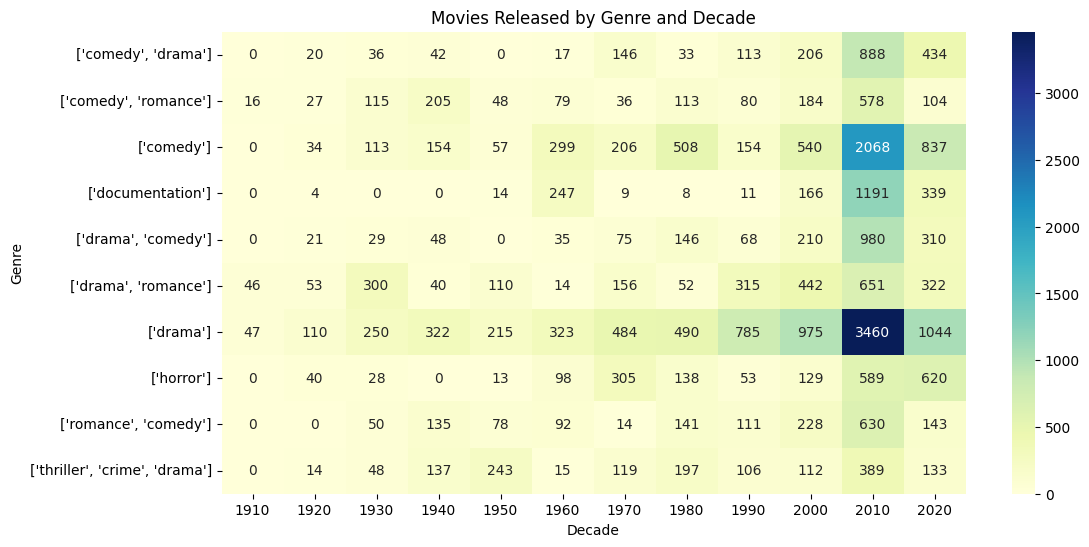

In [ ]:
# Create decade
dataset['Decade'] = (dataset['release_year_cleaned'].dt.year // 10) * 10

# Keep only top 10 genres
top10 = dataset['genres'].value_counts().head(10).index
dataset = dataset[dataset['genres'].isin(top10)]

heatmap = pd.crosstab(dataset['genres'], dataset['Decade'])

plt.figure(figsize=(12,6))

sns.heatmap(heatmap,annot=True,fmt='d', cmap='YlGnBu')

plt.title("Movies Released by Genre and Decade")
plt.xlabel("Decade")
plt.ylabel("Genre")

plt.show()

**How genre preferences changed across decades.**

The 2010s were a content boom decade.

Genre production has evolved significantly over the last century. Drama remained the dominant genre throughout the entire period, while Comedy and Documentary experienced substantial growth after the 2000s. The 2010s marked the largest expansion of content production, coinciding with the rise of global streaming platforms. Additionally, hybrid genres such as Drama–Comedy and Comedy–Romance became increasingly common, suggesting a shift toward more diverse storytelling formats.


**Why this specific chart?**

A heatmap makes it easy to identify patterns, such as which genres were produced more frequently during certain decades, through color intensity. A bar chart would require many separate plots, while the heatmap summarizes all the information in one visualization.

##graph 2

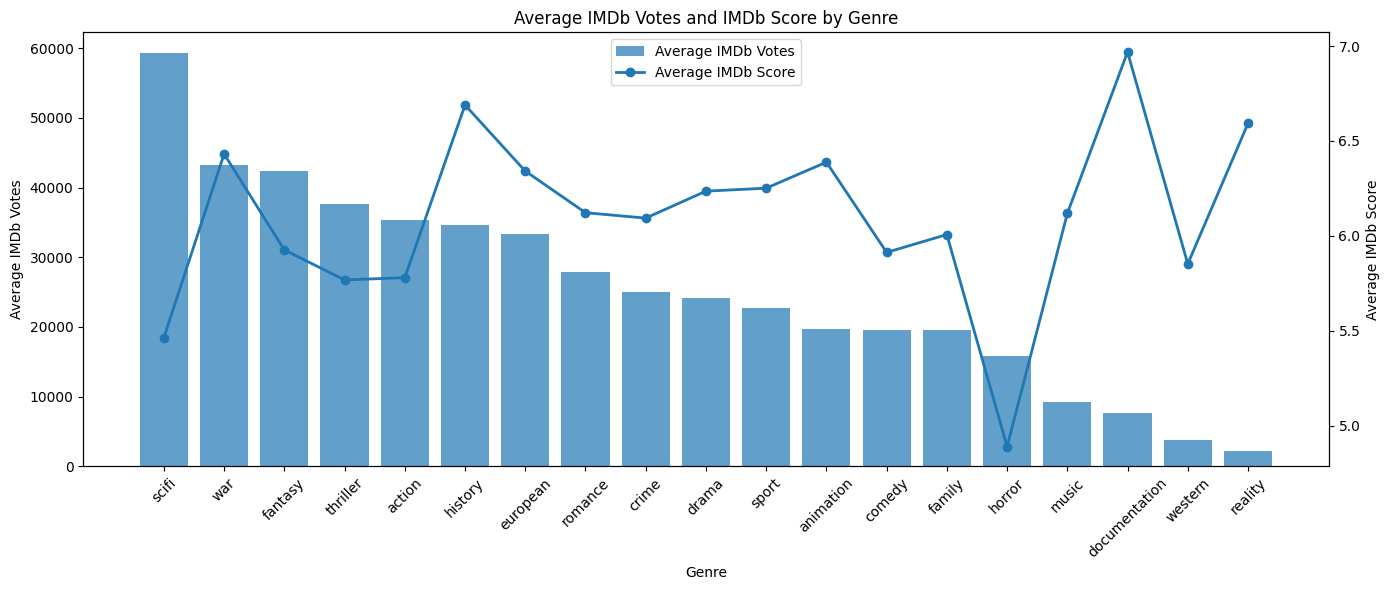

In [ ]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar chart: IMDb Votes
ax1.bar(
    genre_analysis_ratings.index,
    genre_analysis_ratings['imdb_votes'],
    alpha=0.7,
    label='Average IMDb Votes'
)

ax1.set_ylabel('Average IMDb Votes')
ax1.set_xlabel('Genre')
ax1.tick_params(axis='x', rotation=45)

# Line chart: IMDb Score
ax2 = ax1.twinx()

ax2.plot(
    genre_analysis_ratings.index,
    genre_analysis_ratings['imdb_score'],
    marker='o',
    linewidth=2,
    label='Average IMDb Score'
)

ax2.set_ylabel('Average IMDb Score')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc=9
)

plt.title('Average IMDb Votes and IMDb Score by Genre')

plt.tight_layout()
plt.show()

**Key Findings**

1. Sci-Fi has the highest audience engagement but only average ratings

2. War and History are high-potential genres

3. Documentary is a niche but highly appreciated genre

4. Horror has the weakest audience satisfaction

5. Action and Thriller remain commercially attractive

6. Drama continues to perform steadily

7. Comedy shows moderate performance

###**Strong business recommendation**


**For maximum audience reach -**

Sci-Fi

War

Fantasy

Action and Thriller

**For critical acclaim and awards -**

Documentary

History

War

**Lower-priority investment -**

Horror

Western

Reality

**Why this specific chart?**

I wanted to compare two different metrics for the same genre. The bar chart clearly shows IMDb Votes, while the line chart shows the average IMDb score. Using both together allows stakeholders to see whether genres with high intrest also maintain high quality.

##graph 3

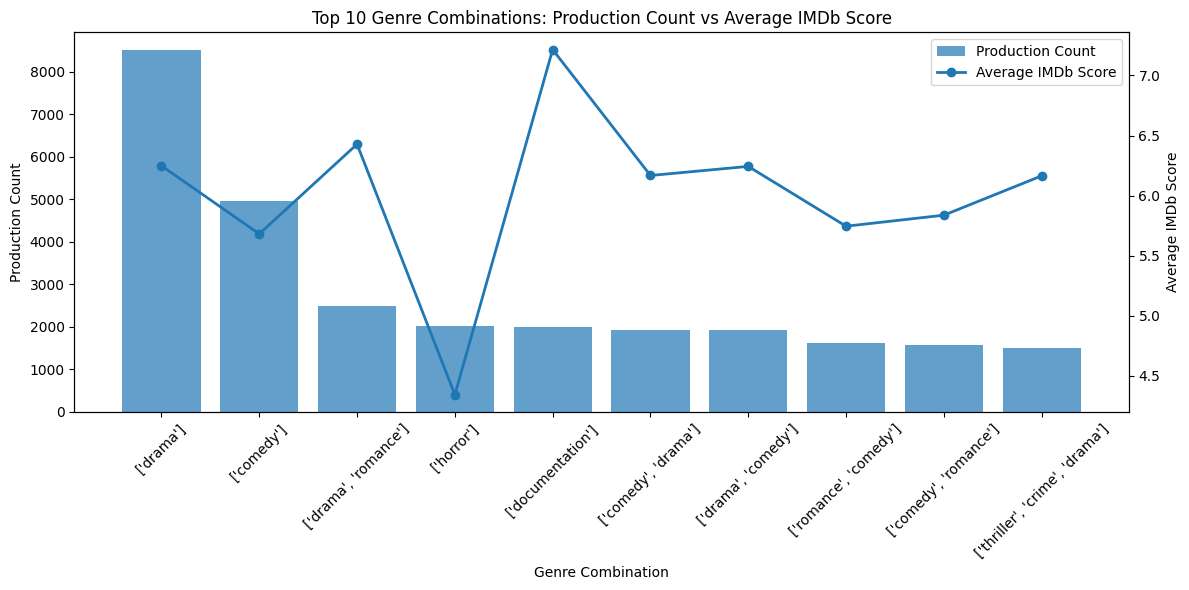

In [ ]:
# Top 10 Genre Combinations by Production Count
top10_production_score = (
    dataset.groupby('genres')
    .agg(
        Production_Count=('title', 'count'),
        Average_IMDb_Score=('imdb_score', 'mean')
    )
    .sort_values('Production_Count', ascending=False)
    .head(10)
)

# Create figure
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar Chart: Production Count
ax1.bar(
    top10_production_score.index,
    top10_production_score['Production_Count'],
    alpha=0.7,
    label='Production Count'
)

ax1.set_xlabel('Genre Combination')
ax1.set_ylabel('Production Count')
ax1.tick_params(axis='x', rotation=45)

# Second axis
ax2 = ax1.twinx()

# Line Chart: Average IMDb Score
ax2.plot(
    top10_production_score.index,
    top10_production_score['Average_IMDb_Score'],
    marker='o',
    linewidth=2,
    label='Average IMDb Score'
)

ax2.set_ylabel('Average IMDb Score')

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper right'
)

plt.title('Top 10 Genre Combinations: Production Count vs Average IMDb Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

### **Are companies producing genres because they're good, or because they're popular?**



1. Drama is the safest investment

Drama is produced the most because it consistently attracts audiences and maintains decent quality ratings.

2. Documentary is quality over quantity

Documentaries receive the best audience ratings despite relatively low production volume, indicating strong viewer satisfaction and niche appeal.

3. Horror is overproduced relative to quality

Horror has a substantial number of productions but receives the lowest ratings, suggesting quantity does not translate into quality.

4. Drama-Romance is underproduced relative to performance

Drama-Romance delivers strong audience satisfaction while being produced far less frequently than Drama or Comedy.

This may indicate an opportunity for additional investment.

5. Comedy is mass-market but average quality

Comedy remains one of the most-produced genres, but viewer ratings are only moderate compared to several other genres.

**Production volume does NOT guarantee quality**

High Production + High Rating =	Drama, Drama-Romance

High Production + Lower Rating	= Comedy, Horror

Low Production + High Rating = Documentary

Low Production + Lower Rating =	Romance-Comedy

**Why this specific chart?**

I wanted to compare two different metrics for the same genre. The bar chart clearly shows production volume, while the line chart shows the average IMDb score. Using both together allows stakeholders to see whether genres with high production also maintain high quality.

##graph 4

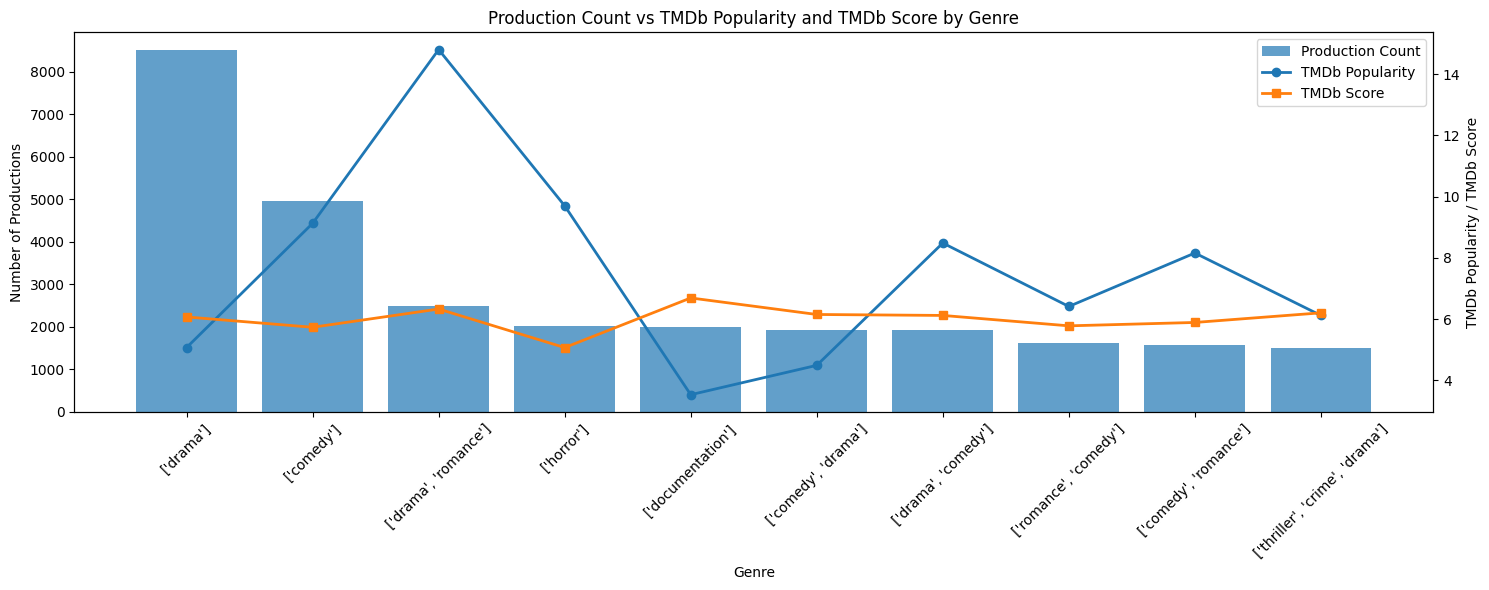

In [ ]:
fig, ax1 = plt.subplots(figsize=(15,6))

# Bar: Number of Productions
ax1.bar(
    genre_tmdb.index,
    genre_tmdb['Production_Count'],
    alpha=0.7,
    label='Production Count'
)

ax1.set_xlabel('Genre')
ax1.set_ylabel('Number of Productions')
ax1.tick_params(axis='x', rotation=45)

# Second axis
ax2 = ax1.twinx()

# TMDb Popularity
ax2.plot(
    genre_tmdb.index,
    genre_tmdb['Avg_TMDb_Popularity'],
    marker='o',
    linewidth=2,
    label='TMDb Popularity'
)

# TMDb Score
ax2.plot(
    genre_tmdb.index,
    genre_tmdb['Avg_TMDb_Score'],
    marker='s',
    linewidth=2,
    label='TMDb Score'
)

ax2.set_ylabel('TMDb Popularity / TMDb Score')

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.title('Production Count vs TMDb Popularity and TMDb Score by Genre')

plt.tight_layout()
plt.show()

**TMDb Popularity and TMDb Score measure different things**

1.Documentary

Low popularity
High score

Meaning: Small audience, highly satisfied.

2.Horror

High popularity
Low score

Meaning: Large audience interest, lower satisfaction.

3.Drama-Romance

High popularity
Good score

Meaning: Strong audience demand and good reception.

##graph 5

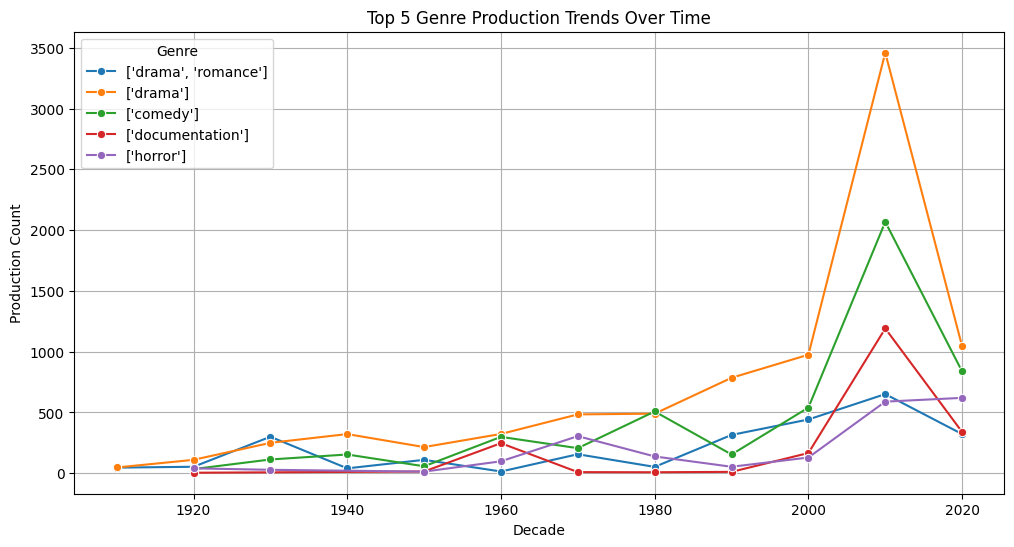

In [ ]:
# Top 5 genres by total production count
top5_genres = (
    dataset['genres']
    .value_counts()
    .head(5)
    .index
)

# Filter dataset
top5_data = dataset[
    dataset['genres'].isin(top5_genres)
]

# Production trend
production_trend = (
    top5_data
    .groupby(['Decade', 'genres'])
    .size()
    .reset_index(name='Production_Count')
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=production_trend,
    x='Decade',
    y='Production_Count',
    hue='genres',
    marker='o'
)

plt.title('Top 5 Genre Production Trends Over Time')
plt.xlabel('Decade')
plt.ylabel('Production Count')
plt.grid(True)
plt.legend(title='Genre')
plt.show()

**Top 5 genres over time.**

1. Drama is the clear market leader


2. Comedy is the second strongest genre


3. Documentary is the fastest-growing niche genre


4. Drama-Romance remains consistently popular


5. Horror is growing, but slower

**Why this specific chart?**

The data changes over time, and line charts are the most effective way to visualize trends.

##graph 6

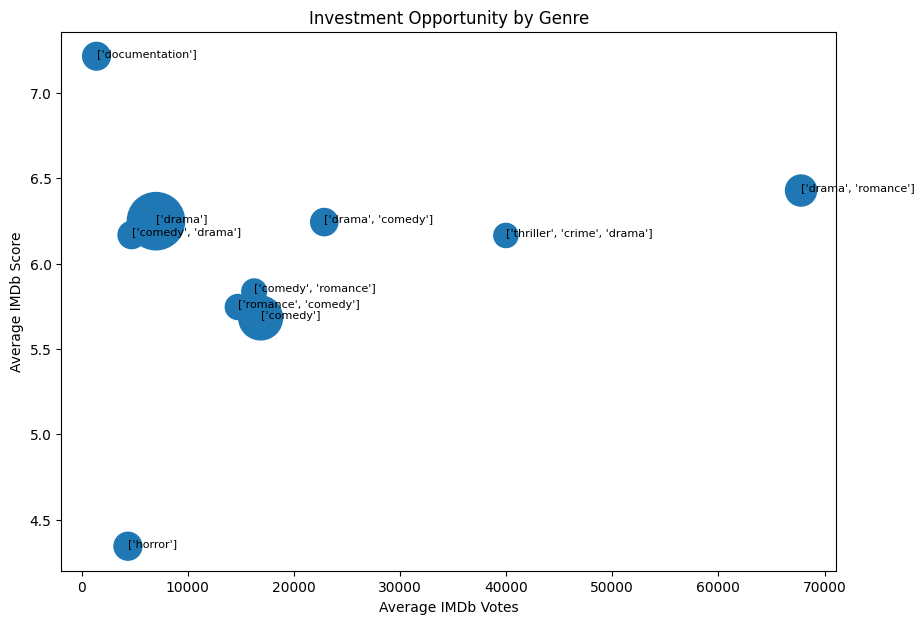

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    investment['IMDb_Votes'],
    investment['IMDb_Score'],
    s=investment['Productions']/5
)

for genre in investment.index:
    plt.text(
        investment.loc[genre,'IMDb_Votes'],
        investment.loc[genre,'IMDb_Score'],
        genre,
        fontsize=8
    )

plt.xlabel("Average IMDb Votes")
plt.ylabel("Average IMDb Score")
plt.title("Investment Opportunity by Genre")

plt.show()

###**Where should a streaming platform invest its next content budget?**


**1. Drama-Romance is the strongest genre**

Located in the top-right area.

Highest IMDb Votes (~68k)

High IMDb Score (~6.4)

Moderate production count

Insight:

Drama-Romance combines strong audience demand and strong audience satisfaction, making it one of the most attractive genres for future investment.

**2. Documentary is a hidden opportunity**

Located in the top-left area.

Highest IMDb Score (~7.2)

Lowest IMDb Votes

Small production volume

Insight:

Documentaries are highly valued by viewers who watch them, but they attract a smaller audience. This suggests a high-quality niche market.

**3. Drama dominates production**

Largest bubble.

Huge production count

Moderate votes

Moderate ratings

Insight:

The industry heavily invests in Drama because it is a proven, low-risk genre.

**4. Horror is the weakest performer**

Bottom-left area.

Low IMDb Votes

Lowest IMDb Score

Moderate production

Insight:

Horror shows weak audience satisfaction and relatively low engagement compared with other genres.

**5. Thriller-Crime-Drama performs very well**

High votes (~40k)

Good score (~6.1)

Insight:

Crime and thriller content attracts substantial audience attention while maintaining good ratings.

**Why this specific chart?**

I chose a scatter plot because I wanted to study the relationship between two numerical variables rather than simply compare them. It helps identify which genres have both high IMDb votes and high IMDb scores, making it easier to spot high-performing genres and potential investment opportunities.

##graph 7

###TV shows VS Movies

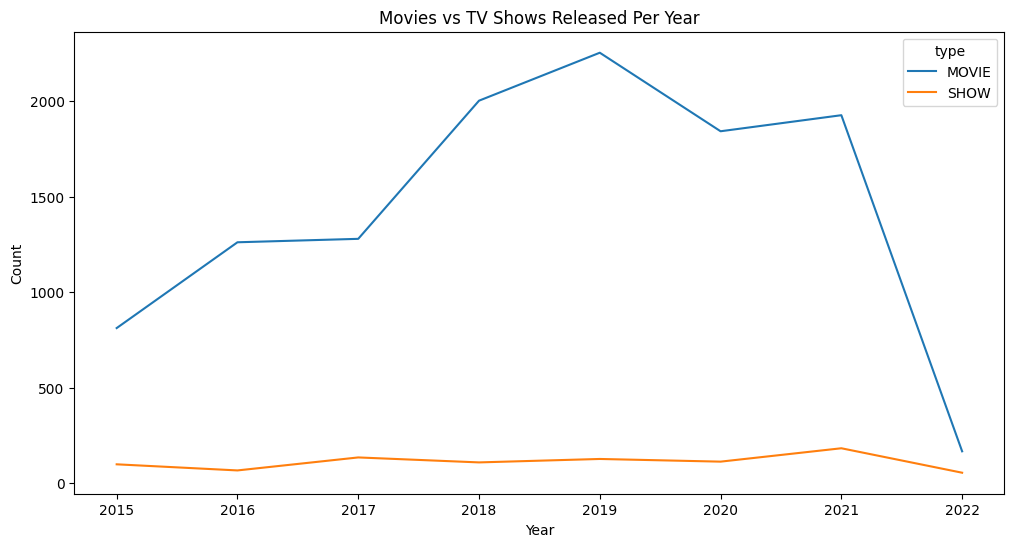

In [ ]:
dataset['Year'] = dataset['release_year_cleaned'].dt.year

yearly = pd.crosstab(
    dataset['Year'],
    dataset['type']
)

yearly = yearly[yearly.index >= 2015]

yearly.plot(figsize=(12,6))
plt.title('Movies vs TV Shows Released Per Year')
plt.ylabel('Count')
plt.show()

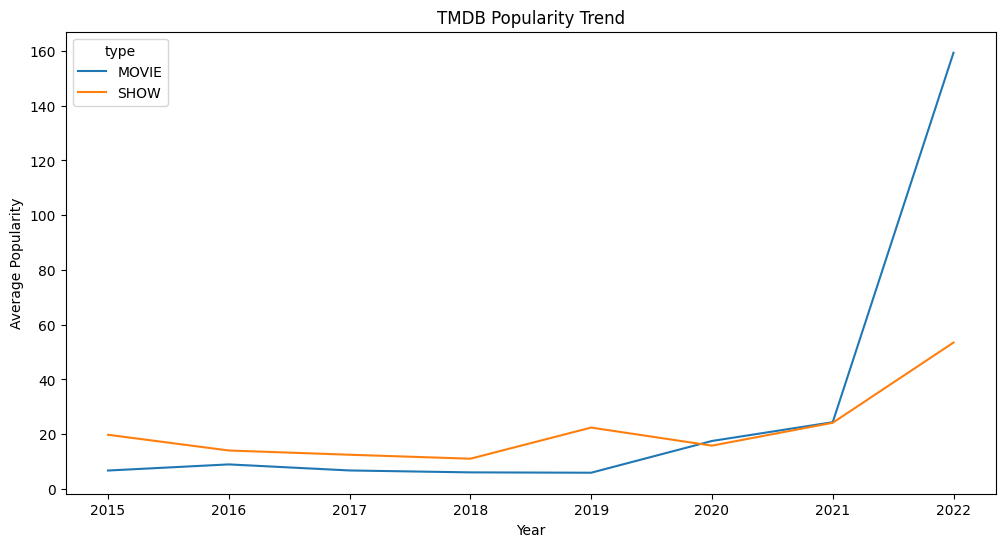

In [ ]:
trend = (
    dataset.groupby(
        [dataset['release_year_cleaned'].dt.year, 'type']
    )['tmdb_popularity']
    .mean()
    .unstack()
)

trend = trend[trend.index >= 2015]

trend.plot(figsize=(12,6))
plt.title('TMDB Popularity Trend')
plt.ylabel('Average Popularity')
plt.xlabel('Year')
plt.show()

**insights**

1.Analysis of content released between 2015 and 2022 reveals that **Movies continue to dominate production volume**, accounting for nearly 90% of titles.

2.However, TV Shows consistently attract strong audience engagement despite representing a much smaller share of releases.

3.TMDB popularity trends indicate growing audience interest in both formats, with **Movies experiencing the strongest growth** in recent years.

**Why this specific chart?**

The data changes over time, and line charts are the most effective way to visualize trends.

# ***4. Conclusion***

**Recommendation:**

Increase investment in Crime and Thriller. Both genres have shown steady production growth since 2010 while maintaining above-average IMDb ratings and strong TMDB popularity, indicating healthy audience demand without excessive market saturation.


**Business Opportunity:**

Documentary and History has one of the highest IMDb scores but comparatively low production volume. This suggests an underserved niche with potential for premium streaming content.

**Warning:**  

Comedy and Horror accounts for the highest production volume but delivers only average audience ratings. Additional investment should prioritize script quality over increasing the number of releases.

**TV Shows vs Movies:**

TV Shows have experienced faster production growth after 2018, while Movies still attract higher audience engagement per title. Consider increasing investment in limited-series formats.